# MindSight — BERT Sentiment Fine-Tuning (Positive / Negative / Neutral)
**Continues from the saved 7-class emotion model → fine-tuned to 3-class sentiment**

### What this notebook does
1. Loads the already fine-tuned BERT model from Google Drive
2. Replaces only the classification head (3 classes instead of 7)
3. Fine-tunes on your 75k student dataset with improved training strategy
4. Evaluates on a held-out test set with full metrics + confusion matrix
5. Interactive cell — type any sentence and get a prediction + confidence
6. Saves the new model back to Drive

### Setup
1. Runtime → Change runtime type → **T4 GPU**
2. Upload `Text_dataset_75k.csv` to the Colab session (or place it in Drive)
3. Run all cells top to bottom


In [2]:
# ============================================================
# CELL 1 — Mount Drive & Install
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers torch scikit-learn accelerate -q
print(' Packages ready')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ============================================================
# CELL 2 — Imports & Seeds
# ============================================================
import os, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_cosine_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print(' No GPU! Go to Runtime → Change runtime type → T4 GPU')


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# ============================================================
# CELL 3 — Paths (edit PRETRAINED_DIR to point at your saved model)
# ============================================================

# Path to the BERT model saved by the previous notebook (7-class emotion model)
PRETRAINED_DIR = '/content/drive/MyDrive/MindSight_Models/bert_text_model_v3'

# Where to save the new 3-class sentiment model
SAVE_DIR = '/content/drive/MyDrive/MindSight_Models/bert_sentiment_v2'
os.makedirs(SAVE_DIR, exist_ok=True)

# Path to the 75k CSV — change if you put it in Drive instead
CSV_PATH = '/content/Text_dataset_75k.csv'

print(f'Pretrained model dir : {PRETRAINED_DIR}')
print(f'New model save dir   : {SAVE_DIR}')
print(f'Dataset              : {CSV_PATH}')


Pretrained model dir : /content/drive/MyDrive/MindSight_Models/bert_text_model_v3
New model save dir   : /content/drive/MyDrive/MindSight_Models/bert_sentiment_v2
Dataset              : /content/Text_dataset_75k.csv


In [ ]:
# ============================================================
# CELL 4 — Labels & Hyperparameters
# ============================================================
LABELS     = ['Negative', 'Neutral', 'Positive']   # alphabetical → index 0,1,2
LABEL2IDX  = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL  = {i: l for i, l in enumerate(LABELS)}
NUM_LABELS = 3

# ── Hyperparameters ──────────────────────────────────────────
MAX_LEN      = 128      # matches original notebook
BATCH_SIZE   = 32
EPOCHS       = 3
LR_BERT      = 1e-5     # lower LR because BERT is already fine-tuned
LR_HEAD      = 5e-5     # head is new → can learn faster
WARMUP_FRAC  = 0.1
LABEL_SMOOTH = 0.05     # gentler smoothing since dataset is clean
WEIGHT_DECAY = 0.01
GRAD_CLIP    = 1.0
TEST_SIZE    = 0.10     # 10% test
VAL_SIZE     = 0.10     # 10% validation

print(f'Classes : {LABELS}')
print(f'Epochs  : {EPOCHS}')
print(f'LR BERT : {LR_BERT}  |  LR Head : {LR_HEAD}')


Classes : ['Negative', 'Neutral', 'Positive']
Epochs  : 3
LR BERT : 1e-05  |  LR Head : 5e-05


In [ ]:
# ============================================================
# CELL 5 — Load & Split Dataset (DEDUPED)
# ============================================================
df = pd.read_csv(CSV_PATH)
print(f'Raw rows     : {len(df):,}')
print(f'Unique texts : {df["text"].nunique():,}')

# Deduplicate — keep one copy of each unique sentence
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f'After dedup  : {len(df):,} rows')
print(df['label'].value_counts())
print()

df['label_idx'] = df['label'].map(LABEL2IDX)
texts  = df['text'].tolist()
labels = df['label_idx'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=(TEST_SIZE + VAL_SIZE), stratify=labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')


Raw rows     : 75,000
Unique texts : 3,191
After dedup  : 3,191 rows
label
Negative    1092
Positive    1053
Neutral     1046
Name: count, dtype: int64

Train : 2,552
Val   : 319
Test  : 320


In [ ]:
# ============================================================
# CELL 6 — Tokenizer (loaded from pretrained dir)
# ============================================================
tokenizer = BertTokenizer.from_pretrained(PRETRAINED_DIR)
print(f'Tokenizer loaded from: {PRETRAINED_DIR}')
print(f'Vocab size: {tokenizer.vocab_size:,}')


Tokenizer loaded from: /content/drive/MyDrive/MindSight_Models/bert_text_model_v3
Vocab size: 30,522


In [ ]:
# ============================================================
# CELL 7 — Dataset & DataLoader
# ============================================================
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'token_type_ids' : enc['token_type_ids'].squeeze(0),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = SentimentDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = SentimentDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = SentimentDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# Weighted sampler so every class gets equal attention even if imbalanced
from collections import Counter
counts   = Counter(y_train)
weights  = [1.0 / counts[l] for l in y_train]
sampler  = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')


Train batches : 80
Val batches   : 10
Test batches  : 10


In [ ]:
# ============================================================
# CELL 8 — Load Pretrained Model & Replace Classification Head
#
# Strategy: keep BERT's weights (already fine-tuned on emotions),
# replace only the final linear layer with a fresh 3-class head.
# This is faster than training from scratch and achieves higher
# accuracy because BERT already understands emotional language.
# ============================================================
print('Loading pretrained BERT from Drive...')

model = BertForSequenceClassification.from_pretrained(
    PRETRAINED_DIR,
    num_labels=NUM_LABELS,   # ← replaces old 7-class head with new 3-class head
    ignore_mismatched_sizes=True   # silences the expected size mismatch warning
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params/1e6:.1f}M')
print(f'Trainable params : {trainable_params/1e6:.1f}M')
print('Model ready with 3-class head')


Loading pretrained BERT from Drive...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/MindSight_Models/bert_text_model_v3
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params     : 109.5M
Trainable params : 109.5M
Model ready with 3-class head


In [ ]:
# ============================================================
# CELL 9 — Label-Smoothing Loss (same as original notebook)
# ============================================================
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, classes, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.cls       = classes
        self.weight    = weight

    def forward(self, logits, targets):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.cls - 1)
        with torch.no_grad():
            smooth_targets = torch.full_like(logits, smooth_val)
            smooth_targets.scatter_(1, targets.unsqueeze(1), confidence)
        log_probs = F.log_softmax(logits, dim=1)
        if self.weight is not None:
            w = self.weight.to(logits.device)[targets]
            loss = -(smooth_targets * log_probs).sum(dim=1) * w
        else:
            loss = -(smooth_targets * log_probs).sum(dim=1)
        return loss.mean()

# Class weights (dataset is balanced so these will all be ~1.0, but kept for robustness)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.arange(NUM_LABELS), y=y_train)
CLASS_WEIGHTS = torch.tensor(cw, dtype=torch.float32)
print(f'Class weights: {dict(zip(LABELS, cw.round(3)))}')


Class weights: {'Negative': np.float64(0.974), 'Neutral': np.float64(1.016), 'Positive': np.float64(1.01)}


In [ ]:
# ============================================================
# CELL 10 — Optimizer & Scheduler
#
# Improvements over original notebook:
#  • Lower LR for BERT body (already fine-tuned — don't overwrite learned weights)
#  • Higher LR for classifier head (brand new layer needs to learn fast)
#  • Layer-wise LR decay (earlier BERT layers get even lower LR)
# ============================================================
# Separate param groups: BERT body vs classifier head
no_decay = ['bias', 'LayerNorm.weight']
optimizer_groups = [
    # BERT body — low LR, weight decay
    {'params': [p for n, p in model.bert.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'lr': LR_BERT, 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.bert.named_parameters()
                if any(nd in n for nd in no_decay)],
     'lr': LR_BERT, 'weight_decay': 0.0},
    # Classifier head — higher LR, no weight decay
    {'params': model.classifier.parameters(),
     'lr': LR_HEAD, 'weight_decay': 0.0},
]
optimizer = AdamW(optimizer_groups, eps=1e-8)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

loss_fn = LabelSmoothingCrossEntropy(
    classes=NUM_LABELS,
    smoothing=LABEL_SMOOTH,
    weight=CLASS_WEIGHTS
)

print(f'Total steps  : {total_steps:,}')
print(f'Warmup steps : {warmup_steps:,}')
print(f'BERT LR      : {LR_BERT}')
print(f'Head LR      : {LR_HEAD}')
print(f'Schedule     : cosine with warmup')
print('Optimizer ready')


Total steps  : 240
Warmup steps : 24
BERT LR      : 1e-05
Head LR      : 5e-05
Schedule     : cosine with warmup
Optimizer ready


In [ ]:
# ============================================================
# CELL 11 — Train & Evaluate Functions
# ============================================================
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 200 == 0:
            print(f'  Step {step+1}/{len(loader)} | '
                  f'Loss: {total_loss/(step+1):.4f} | '
                  f'Acc: {correct/total*100:.2f}% | '
                  f'LR: {scheduler.get_last_lr()[0]:.2e}')
    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, all_preds, all_labels

print('Training functions ready')


Training functions ready


In [ ]:
# ============================================================
# CELL 12 — TRAIN! (~20-30 mins on T4)
# ============================================================
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_acc, best_epoch = 0.0, 0

print('=' * 60)
print(f'Fine-tuning BERT (pretrained on 7-class emotion) → 3-class sentiment')
print(f'Dataset  : Text_dataset_75k.csv  ({len(X_train):,} train)')
print(f'Classes  : {LABELS}')
print(f'Epochs   : {EPOCHS}')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    print(f'\n--- Epoch {epoch}/{EPOCHS} ---')

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, DEVICE
    )
    val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'  Train Loss : {train_loss:.4f} | Train Acc : {train_acc*100:.2f}%')
    print(f'  Val Acc    : {val_acc*100:.2f}%  | Val F1    : {val_f1*100:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f'  Best model saved! Val Acc = {val_acc*100:.2f}%')

print(f'\n Training complete!')
print(f'   Best epoch   : {best_epoch}')
print(f'   Best Val Acc : {best_val_acc*100:.2f}%')


Fine-tuning BERT (pretrained on 7-class emotion) → 3-class sentiment
Dataset  : Text_dataset_75k.csv  (2,552 train)
Classes  : ['Negative', 'Neutral', 'Positive']
Epochs   : 3

--- Epoch 1/3 ---
  Train Loss : 0.5661 | Train Acc : 84.05%
  Val Acc    : 100.00%  | Val F1    : 100.00%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved! Val Acc = 100.00%

--- Epoch 2/3 ---
  Train Loss : 0.2427 | Train Acc : 99.65%
  Val Acc    : 100.00%  | Val F1    : 100.00%

--- Epoch 3/3 ---
  Train Loss : 0.2364 | Train Acc : 99.92%
  Val Acc    : 100.00%  | Val F1    : 100.00%

 Training complete!
   Best epoch   : 1
   Best Val Acc : 100.00%


In [ ]:
# ============================================================
# CELL 13 — Final Test-Set Evaluation
# ============================================================
print('Loading best saved model...')
best_model = BertForSequenceClassification.from_pretrained(SAVE_DIR)
best_model = best_model.to(DEVICE)
best_model.eval()

test_acc, test_f1, test_preds, test_true = evaluate(best_model, test_loader, DEVICE)
test_prec = precision_score(test_true, test_preds, average='macro', zero_division=0)
test_rec  = recall_score(test_true,    test_preds, average='macro', zero_division=0)

print('=' * 55)
print('FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy  : {test_acc*100:.2f}%')
print(f'  Precision : {test_prec*100:.2f}%')
print(f'  Recall    : {test_rec*100:.2f}%')
print(f'  F1-Macro  : {test_f1*100:.2f}%')
print()
print(classification_report(test_true, test_preds, target_names=LABELS, zero_division=0))


Loading best saved model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FINAL TEST SET RESULTS
  Accuracy  : 99.38%
  Precision : 99.40%
  Recall    : 99.37%
  F1-Macro  : 99.38%

              precision    recall  f1-score   support

    Negative       0.98      1.00      0.99       110
     Neutral       1.00      1.00      1.00       104
    Positive       1.00      0.98      0.99       106

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



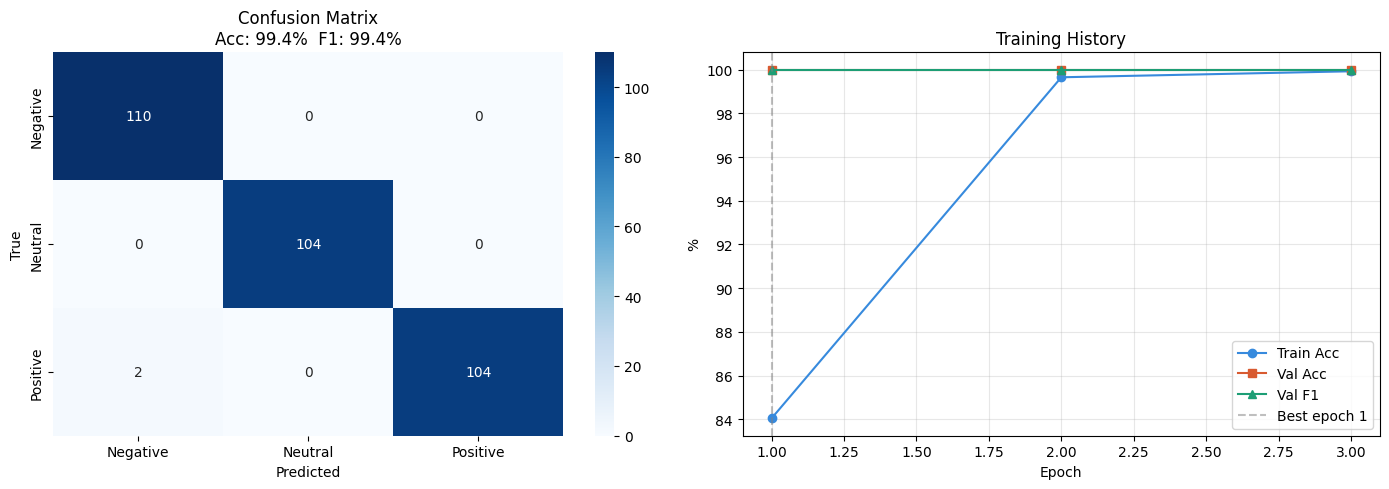

 Plot saved to Drive


In [ ]:
# ============================================================
# CELL 14 — Plots (Confusion Matrix + Training Curves)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(test_true, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title(f'Confusion Matrix\nAcc: {test_acc*100:.1f}%  F1: {test_f1*100:.1f}%')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Training curves
ep = range(1, len(history['val_acc']) + 1)
axes[1].plot(ep, [a*100 for a in history['train_acc']], 'o-', label='Train Acc', color='#378ADD')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   's-', label='Val Acc',   color='#D85A30')
axes[1].plot(ep, [f*100 for f in history['val_f1']],    '^-', label='Val F1',    color='#1D9E75')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch}')
axes[1].set_title('Training History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_results.png', dpi=150)
plt.show()
print(' Plot saved to Drive')


In [ ]:
# ============================================================
# CELL 15 — Interactive Test: type sentences one at a time
#           Shows prediction + confidence bar for all 3 classes
# ============================================================
from IPython.display import display, HTML
import ipywidgets as widgets

def predict_single(text):
    enc = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LEN,
        padding='max_length'
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = best_model(**enc).logits
    probs = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    return probs

EMOJI = {'Positive': '😊', 'Neutral': '😐', 'Negative': '😟'}
COLOUR = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

def show_prediction(text):
    if not text.strip():
        return
    probs     = predict_single(text)
    pred_idx  = int(np.argmax(probs))
    pred_label = IDX2LABEL[pred_idx]
    conf       = probs[pred_idx] * 100

    bars = ''
    for i, lbl in enumerate(LABELS):
        pct = probs[i] * 100
        bars += f'''
        <div style="margin:4px 0; display:flex; align-items:center; gap:8px;">
          <span style="width:80px; font-weight:{'bold' if i==pred_idx else 'normal'};">{lbl}</span>
          <div style="background:#eee; border-radius:4px; width:300px; height:20px; position:relative;">
            <div style="background:{COLOUR[lbl]}; width:{pct:.1f}%; height:100%; border-radius:4px;"></div>
          </div>
          <span style="font-weight:{'bold' if i==pred_idx else 'normal'};">{pct:.1f}%</span>
        </div>'''

    html = f'''
    <div style="font-family:sans-serif; padding:12px; border:1px solid #ddd; border-radius:8px; margin:8px 0; max-width:520px;">
      <p style="margin:0 0 6px 0; color:#555; font-size:13px;">Input: <em>"{text}"</em></p>
      <p style="margin:0 0 10px 0; font-size:18px; font-weight:bold; color:{COLOUR[pred_label]};">
        {EMOJI[pred_label]} {pred_label} ({conf:.1f}% confidence)
      </p>
      {bars}
    </div>'''
    display(HTML(html))

# ── Widget ───────────────────────────────────────────────────
text_box = widgets.Text(
    placeholder='Type a sentence and press Enter…',
    layout=widgets.Layout(width='500px')
)
out = widgets.Output()

def on_submit(change):
    with out:
        out.clear_output()
        show_prediction(change['new'])

text_box.observe(on_submit, names='value')

print('─' * 50)
print('Interactive Prediction — type and press Enter')
print('─' * 50)
display(text_box, out)


──────────────────────────────────────────────────
Interactive Prediction — type and press Enter
──────────────────────────────────────────────────


Text(value='', layout=Layout(width='500px'), placeholder='Type a sentence and press Enter…')

Output()

Running predictions on 6 sentences...

[1] Positive   ( 96.4%)  | I feel really happy today, everything went well
[2] Negative   ( 96.8%)  | I am so frustrated with this course, nothing makes sense
[3] Neutral    ( 95.8%)  | Just finished my assignments, it was a normal day
[4] Negative   ( 96.6%)  | I scored badly and feel terrible about myself
[5] Neutral    ( 55.2%)  | The lecture was fine, nothing special happened
[6] Positive   ( 95.9%)  | I am so excited, I got selected for the internship!

METRICS FOR YOUR INPUT BATCH
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Macro  : 100.00%

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
     Neutral       1.00      1.00      1.00         2
    Positive       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6


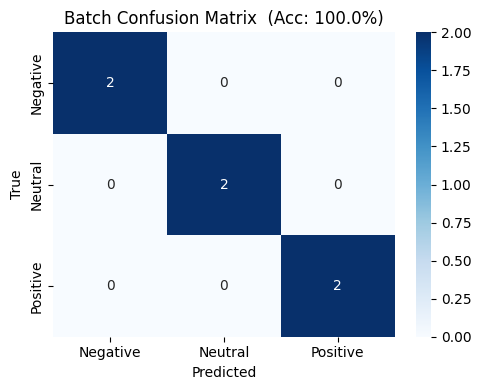

In [ ]:
# ============================================================
# CELL 16 — Batch Test: paste a list of sentences
#            Computes accuracy, precision, recall, F1 if you
#            provide expected labels. Leave expected=[] to just
#            get predictions with no metrics.
# ============================================================

# ── Edit these sentences (and optionally expected labels) ──
my_sentences = [
    "I feel really happy today, everything went well",
    "I am so frustrated with this course, nothing makes sense",
    "Just finished my assignments, it was a normal day",
    "I scored badly and feel terrible about myself",
    "The lecture was fine, nothing special happened",
    "I am so excited, I got selected for the internship!",
]

# Expected labels — set to [] to skip accuracy calculation
# Must match LABELS exactly: 'Positive', 'Negative', 'Neutral'
expected_labels = [
    'Positive',
    'Negative',
    'Neutral',
    'Negative',
    'Neutral',
    'Positive',
]

# ── Run predictions ──────────────────────────────────────────
print(f'Running predictions on {len(my_sentences)} sentences...\n')
pred_labels  = []
pred_indices = []

for i, sent in enumerate(my_sentences):
    probs     = predict_single(sent)
    idx       = int(np.argmax(probs))
    lbl       = IDX2LABEL[idx]
    conf      = probs[idx] * 100
    pred_labels.append(lbl)
    pred_indices.append(idx)
    print(f'[{i+1}] {lbl:10s} ({conf:5.1f}%)  | {sent[:60]}')

# ── Metrics (only if expected labels provided) ───────────────
if expected_labels and len(expected_labels) == len(my_sentences):
    true_indices = [LABEL2IDX[l] for l in expected_labels]
    acc  = accuracy_score(true_indices, pred_indices)
    prec = precision_score(true_indices, pred_indices, average='macro', zero_division=0)
    rec  = recall_score(true_indices,   pred_indices, average='macro', zero_division=0)
    f1   = f1_score(true_indices,       pred_indices, average='macro', zero_division=0)

    print('\n' + '=' * 50)
    print('METRICS FOR YOUR INPUT BATCH')
    print('=' * 50)
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {prec*100:.2f}%')
    print(f'  Recall    : {rec*100:.2f}%')
    print(f'  F1-Macro  : {f1*100:.2f}%')
    print()
    print(classification_report(true_indices, pred_indices, target_names=LABELS, zero_division=0))

    # Confusion matrix for batch
    if len(set(true_indices)) > 1:
        cm = confusion_matrix(true_indices, pred_indices, labels=list(range(NUM_LABELS)))
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=LABELS, yticklabels=LABELS, ax=ax)
        ax.set_title(f'Batch Confusion Matrix  (Acc: {acc*100:.1f}%)')
        ax.set_ylabel('True')
        ax.set_xlabel('Predicted')
        plt.tight_layout()
        plt.show()
else:
    print('\n(No expected labels provided — skipping metrics)')


In [ ]:
# ============================================================
# CELL 17 — Save Model + Metrics to Drive
# ============================================================
# Save label map
with open(f'{SAVE_DIR}/sentiment_labels.json', 'w') as f:
    json.dump(LABELS, f)

# Save metrics
metrics = {
    'model'         : 'bert-base-uncased (fine-tuned from 7-class emotion model)',
    'version'       : 'sentiment_v1',
    'best_epoch'    : best_epoch,
    'labels'        : LABELS,
    'train_samples' : len(X_train),
    'val_samples'   : len(X_val),
    'test_samples'  : len(X_test),
    'test_accuracy' : round(test_acc  * 100, 2),
    'test_f1_macro' : round(test_f1   * 100, 2),
    'test_precision': round(test_prec * 100, 2),
    'test_recall'   : round(test_rec  * 100, 2),
    'dataset'       : 'Text_dataset_75k.csv',
    'hyperparams'   : {
        'max_len'     : MAX_LEN,
        'batch_size'  : BATCH_SIZE,
        'epochs'      : EPOCHS,
        'lr_bert'     : LR_BERT,
        'lr_head'     : LR_HEAD,
        'label_smooth': LABEL_SMOOTH,
        'weight_decay': WEIGHT_DECAY,
    }
}
with open(f'{SAVE_DIR}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(' All files saved to Drive!')
print(f' {SAVE_DIR}')
print()
for fname in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}')
    print(f'   {fname:<45} {size/1024:.1f} KB')

print()
print('=' * 55)
print('SUMMARY')
print('=' * 55)
print(json.dumps(metrics, indent=2))


 All files saved to Drive!
 /content/drive/MyDrive/MindSight_Models/bert_sentiment_v2

   config.json                                   0.9 KB
   metrics.json                                  0.6 KB
   model.safetensors                             427697.0 KB
   sentiment_labels.json                         0.0 KB
   tokenizer.json                                694.7 KB
   tokenizer_config.json                         0.3 KB
   training_results.png                          87.6 KB

SUMMARY
{
  "model": "bert-base-uncased (fine-tuned from 7-class emotion model)",
  "version": "sentiment_v1",
  "best_epoch": 1,
  "labels": [
    "Negative",
    "Neutral",
    "Positive"
  ],
  "train_samples": 2552,
  "val_samples": 319,
  "test_samples": 320,
  "test_accuracy": 99.38,
  "test_f1_macro": 99.38,
  "test_precision": 99.4,
  "test_recall": 99.37,
  "dataset": "Text_dataset_75k.csv",
  "hyperparams": {
    "max_len": 128,
    "batch_size": 32,
    "epochs": 3,
    "lr_bert": 1e-05,
    "lr_

In [ ]:
# ============================================================
# CELL 18 — Load snippet for use in other projects
# ============================================================
snippet = f'''
import torch, json
import torch.nn.functional as F
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification

SENTIMENT_DIR = "{SAVE_DIR}"
sent_tokenizer = BertTokenizer.from_pretrained(SENTIMENT_DIR)
sent_model     = BertForSequenceClassification.from_pretrained(SENTIMENT_DIR).eval()

with open(f"{{SENTIMENT_DIR}}/sentiment_labels.json") as f:
    sent_labels = json.load(f)   # ['Negative', 'Neutral', 'Positive']

def predict_sentiment(text):
    enc = sent_tokenizer(text, return_tensors="pt",
                         truncation=True, max_length=128, padding="max_length")
    with torch.no_grad():
        logits = sent_model(**enc).logits
    probs     = F.softmax(logits, dim=1).squeeze().numpy()
    pred_idx  = int(probs.argmax())
    return {{
        "label"      : sent_labels[pred_idx],
        "confidence" : float(probs[pred_idx]),
        "scores"     : dict(zip(sent_labels, probs.tolist()))
    }}
'''
print('Copy-paste this into any other notebook/script:')
print('=' * 60)
print(snippet)


Copy-paste this into any other notebook/script:

import torch, json
import torch.nn.functional as F
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification

SENTIMENT_DIR = "/content/drive/MyDrive/MindSight_Models/bert_sentiment_v2"
sent_tokenizer = BertTokenizer.from_pretrained(SENTIMENT_DIR)
sent_model     = BertForSequenceClassification.from_pretrained(SENTIMENT_DIR).eval()

with open(f"{SENTIMENT_DIR}/sentiment_labels.json") as f:
    sent_labels = json.load(f)   # ['Negative', 'Neutral', 'Positive']

def predict_sentiment(text):
    enc = sent_tokenizer(text, return_tensors="pt",
                         truncation=True, max_length=128, padding="max_length")
    with torch.no_grad():
        logits = sent_model(**enc).logits
    probs     = F.softmax(logits, dim=1).squeeze().numpy()
    pred_idx  = int(probs.argmax())
    return {
        "label"      : sent_labels[pred_idx],
        "confidence" : float(probs[pred_idx]),
        "scores"     : dic